In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

In [26]:
df = pd.read_csv("cc_fraud.csv")

In [27]:
df.head()

,DOMAIN,STATE,ZIPCODE,TIME1,TIME2,VIS1,VIS2,XRN1,XRN2,XRN3,XRN4,XRN5,VAR1,VAR2,VAR3,VAR4,VAR5,TRN_AMT,TOTAL_TRN_AMT,TRN_TYPE
0,CDRZLKAJIJVQHCN.COM,AO,675,12,12,1,0,0,1,1,0,1,2,1,16.680,34,0,12.95,12.95,LEGIT
1,NEKSXUK.NET,KK,680,18,18,1,0,0,0,0,0,1,3,0,37.880,23,0,38.85,38.85,LEGIT
2,XOSOP.COM,UO,432,3,3,1,0,0,1,1,0,1,3,1,-9.080,19,2,38.85,38.85,LEGIT
3,TMA.COM,KR,119,23,23,0,0,1,0,0,0,3,0,0,-6.392,18,0,11.01,11.01,LEGIT
4,VUHZRNB.COM,PO,614,9,9,0,0,0,1,0,0,1,3,0,42.512,7,0,12.95,12.95,LEGIT


In [28]:
label_mapping = {
    'LEGIT': 0,  # Majority class (Non-event)
    'FRAUD': 1   # Minority class (Event of interest)
}
df['TRN_TYPE'] = df['TRN_TYPE'].replace(label_mapping)

C:\Users\63929\AppData\Local\Temp\ipykernel_7604\3229215951.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['TRN_TYPE'] = df['TRN_TYPE'].replace(label_mapping)


In [29]:
counts = df['TRN_TYPE'].value_counts()
print(counts)

TRN_TYPE
0    92588
1     2094
Name: count, dtype: int64


In [30]:
# Encode categorical features
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [31]:
# Split features and target
X = df.drop("TRN_TYPE", axis=1).values
y = df["TRN_TYPE"].values

In [32]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [33]:
cart = DecisionTreeClassifier(
    criterion="gini",   # CART uses Gini by default
    random_state=42
)

In [34]:
cart.fit(X_train, y_train)
y_pred = cart.predict(X_test)

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9589156838584756


In [36]:
accuracy = 0.9587
remaining = 1.0 - accuracy
sizes = [accuracy, remaining]
labels = [f'Accuracy: {accuracy:.2%}', 'Error']
colors = ['skyblue', 'lightgray']
explode = [0, 0]

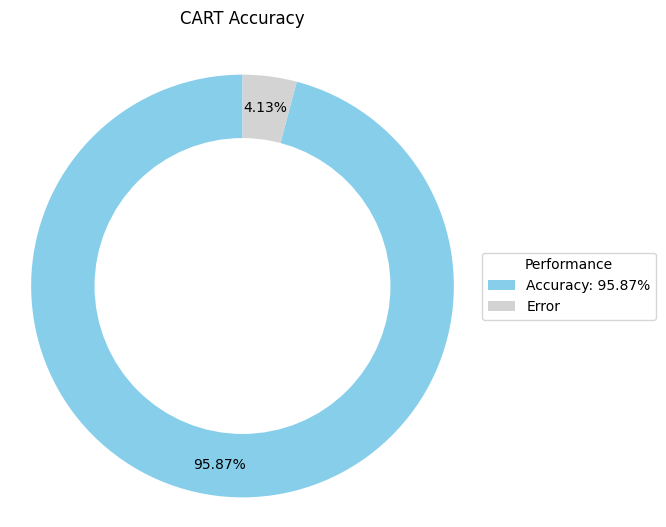

In [37]:
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    autopct='%1.2f%%',  
    startangle=90,      
    colors=colors,
    explode=explode,
    pctdistance=0.85   
)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
plt.title('CART Accuracy', y=1.05)
plt.legend(wedges, labels, title="Performance", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

ax.axis('equal')

plt.show()

In [38]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     27777
           1       0.14      0.16      0.15       628

    accuracy                           0.96     28405
   macro avg       0.56      0.57      0.56     28405
weighted avg       0.96      0.96      0.96     28405



In [39]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.drop(columns=['support'])
df_plot = df_report.iloc[[0, 1]][['precision', 'recall', 'f1-score']]

<Axes: >

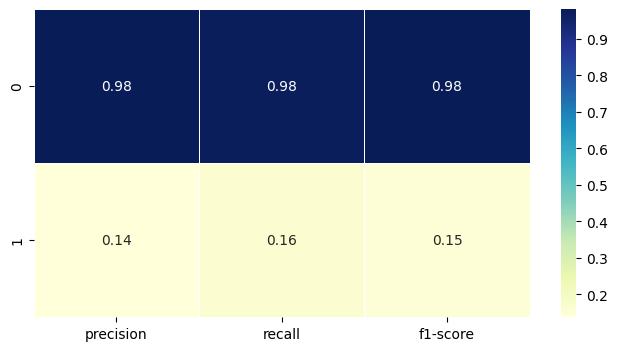

In [40]:
plt.figure(figsize=(8, 4))
sns.heatmap(
    df_plot,
    annot=True,            # Show the numeric value in each cell
    fmt=".2f",             # Format to 2 decimal places
    cmap="YlGnBu",         # Color map (Yellow-Green-Blue is often good)
    cbar=True,             # Display the color bar
    linewidths=.5,         # Add lines for separation
)

In [41]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[27136   641]
 [  526   102]]


In [42]:
cm = confusion_matrix(y_test, y_pred)

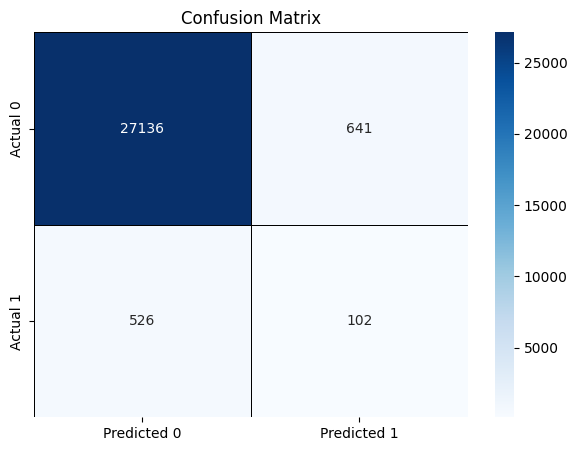

In [43]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,              # Show the numbers inside the cells
    fmt="d",                 # Format the numbers as integers (d for decimal)
    cmap='Blues',            # Color map
    linewidths=.5,           # Add lines between cells
    linecolor='black',
    
    # Set labels for the axes
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title('Confusion Matrix')
plt.show()

In [44]:
scores = cross_val_score(cart, X, y, cv=5, scoring='f1')  
print(f"Cross-validation scores: {scores}")
print(f"Mean score: {np.mean(scores)}")
print(f"Variance: {np.var(scores)}")

Cross-validation scores: [0.1301908  0.1655481  0.14895947 0.16079295 0.14102564]
Mean score: 0.14930339242392768
Variance: 0.00016596623985602735


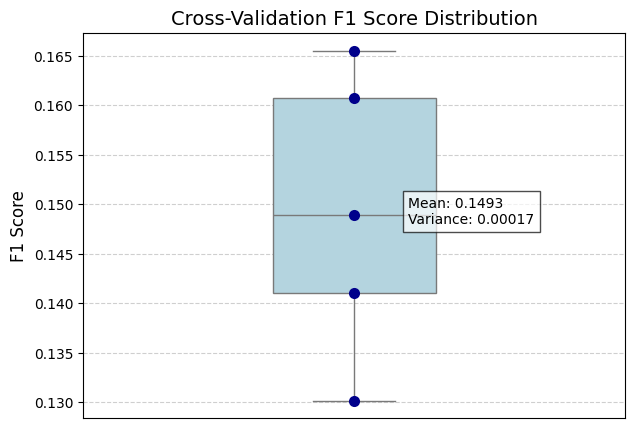

In [45]:
plt.figure(figsize=(7, 5))
sns.boxplot(y=scores, color='lightblue', width=0.3)
sns.stripplot(y=scores, color='darkblue', size=8, jitter=False)

plt.title('Cross-Validation F1 Score Distribution', fontsize=14)
plt.ylabel('F1 Score', fontsize=12)
plt.xticks([]) # Hide x-axis labels since there's only one box
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Optional: Annotate the mean and variance on the plot
mean_score = np.mean(scores)
var_score = np.var(scores)
plt.text(0.1, mean_score, 
         f'Mean: {mean_score:.4f}\nVariance: {var_score:.5f}', 
         ha='left', va='center', 
         bbox=dict(facecolor='white', alpha=0.7))

plt.show()